In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Question3

(a)Downloading

In [2]:
import pandas as pd
import os

def load_instance(filepath):
    df = pd.read_csv(filepath, comment='#', header=None,
                      names=['time','avg_rss12','var_rss12','avg_rss13',
                             'var_rss13','avg_rss23','var_rss23'])
    return df.drop(columns='time')

(b)Train/Test

In [3]:
folders = ['bending1','bending2','cycling','lying','sitting','standing','walking']
base_path = '/content/drive/MyDrive/USC_Summer26/EE559/Data/AReM'

train_files, test_files = [], []

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    files = sorted(os.listdir(folder_path))
    for f in files:
        idx = int(''.join(filter(str.isdigit, f)))
        full_path = os.path.join(folder_path, f)
        if folder in ['bending1','bending2']:
            if idx in [1,2]:
                test_files.append((full_path, folder))
            else:
                train_files.append((full_path, folder))
        else:
            if idx in [1,2,3]:
                test_files.append((full_path, folder))
            else:
                train_files.append((full_path, folder))

(c)i_time-domian

Including min, max, mean, median, std, Q1, Q3 (7 features * 6 time series = 42 features per instance)

(c)ii_feature extraction

In [4]:
def find_bad_files(file_list):
    bad_files = []
    for path, label in file_list:
        try:
            pd.read_csv(path, comment='#', header=None)
        except Exception as e:
            print(f"❌ {path}\n   {e}\n")
            bad_files.append(path)
    return bad_files

bad_train = find_bad_files(train_files)
bad_test  = find_bad_files(test_files)
print("Total bad files:", len(bad_train) + len(bad_test))

❌ /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset14.csv
   Error tokenizing data. C error: Expected 7 fields in line 485, saw 8


❌ /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset9.csv
   Error tokenizing data. C error: Expected 7 fields in line 485, saw 8


Total bad files: 2


In [5]:
def load_instance(filepath):
    """Load a single AReM CSV file, robust to minor formatting errors like trailing commas."""
    try:
        df = pd.read_csv(filepath, comment='#', header=None,
                          names=['time','avg_rss12','var_rss12','avg_rss13',
                                 'var_rss13','avg_rss23','var_rss23'])
    except pd.errors.ParserError:
        with open(filepath) as f:
            raw_lines = f.readlines()
        cleaned_lines = [line.rstrip('\n').rstrip(',') + '\n'
                          for line in raw_lines if not line.startswith('#')]
        from io import StringIO
        df = pd.read_csv(StringIO(''.join(cleaned_lines)), header=None,
                          names=['time','avg_rss12','var_rss12','avg_rss13',
                                 'var_rss13','avg_rss23','var_rss23'])
        print(f"⚠️  Cleaned trailing comma issue in: {filepath}")

    df = df.drop(columns='time')
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all')
    return df

In [6]:
import numpy as np

def extract_features(df):
    feats = {}
    for col in df.columns:
        s = df[col]
        feats[f'min_{col}']    = s.min()
        feats[f'max_{col}']    = s.max()
        feats[f'mean_{col}']   = s.mean()
        feats[f'median_{col}'] = s.median()
        feats[f'std_{col}']    = s.std()
        feats[f'q1_{col}']     = s.quantile(0.25)
        feats[f'q3_{col}']     = s.quantile(0.75)
    return feats

def build_dataset(file_list):
    rows = []
    for path, label in file_list:
        df = load_instance(path)
        feats = extract_features(df)
        feats['label'] = label
        rows.append(feats)
    return pd.DataFrame(rows)

train_df = build_dataset(train_files)
test_df  = build_dataset(test_files)

⚠️  Cleaned trailing comma issue in: /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset14.csv
⚠️  Cleaned trailing comma issue in: /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset9.csv


In [7]:
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("\ntrain_df columns:", list(train_df.columns))
print("\n", train_df.head())

train_df shape: (69, 43)
test_df shape: (19, 43)

train_df columns: ['min_avg_rss12', 'max_avg_rss12', 'mean_avg_rss12', 'median_avg_rss12', 'std_avg_rss12', 'q1_avg_rss12', 'q3_avg_rss12', 'min_var_rss12', 'max_var_rss12', 'mean_var_rss12', 'median_var_rss12', 'std_var_rss12', 'q1_var_rss12', 'q3_var_rss12', 'min_avg_rss13', 'max_avg_rss13', 'mean_avg_rss13', 'median_avg_rss13', 'std_avg_rss13', 'q1_avg_rss13', 'q3_avg_rss13', 'min_var_rss13', 'max_var_rss13', 'mean_var_rss13', 'median_var_rss13', 'std_var_rss13', 'q1_var_rss13', 'q3_var_rss13', 'min_avg_rss23', 'max_avg_rss23', 'mean_avg_rss23', 'median_avg_rss23', 'std_avg_rss23', 'q1_avg_rss23', 'q3_avg_rss23', 'min_var_rss23', 'max_var_rss23', 'mean_var_rss23', 'median_var_rss23', 'std_var_rss23', 'q1_var_rss23', 'q3_var_rss23', 'label']

    min_avg_rss12  max_avg_rss12  mean_avg_rss12  median_avg_rss12  \
0          35.00          47.40       43.954500             44.33   
1          33.00          47.75       42.179812         

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(train_df.head())

   min_avg_rss12  max_avg_rss12  mean_avg_rss12  median_avg_rss12  \
0          35.00          47.40       43.954500             44.33   
1          33.00          47.75       42.179812             43.50   
2          33.00          45.75       41.678063             41.75   
3          37.00          48.00       43.454958             43.25   
4          36.25          48.00       43.969125             44.50   

   std_avg_rss12  q1_avg_rss12  q3_avg_rss12  min_var_rss12  max_var_rss12  \
0       1.558835         43.00         45.00            0.0           1.70   
1       3.670666         39.15         45.00            0.0           3.00   
2       2.243490         41.33         42.75            0.0           2.83   
3       1.386098         42.50         45.00            0.0           1.58   
4       1.618364         43.31         44.67            0.0           1.50   

   mean_var_rss12  median_var_rss12  std_var_rss12  q1_var_rss12  \
0        0.426250              0.47       0.3386

(c)iii_Bootstrap Confidence

In [9]:
def bootstrap_std_ci(data, n_boot=2000, ci=0.90, seed=42):
    rng = np.random.default_rng(seed)
    n = len(data)
    boot_stds = np.empty(n_boot)
    for b in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stds[b] = np.std(sample, ddof=1)
    alpha = 1 - ci
    lower = np.percentile(boot_stds, 100 * alpha / 2)
    upper = np.percentile(boot_stds, 100 * (1 - alpha / 2))
    return np.std(data, ddof=1), lower, upper

feature_cols = [c for c in train_df.columns if c != 'label']

results = {}
for col in feature_cols:
    point_est, lo, hi = bootstrap_std_ci(train_df[col].dropna().values)
    results[col] = {'std': point_est, 'ci_lower': lo, 'ci_upper': hi}

ci_df = pd.DataFrame(results).T
ci_df

,std,ci_lower,ci_upper
min_avg_rss12,8.856393,7.574345,10.131098
max_avg_rss12,4.192017,3.013055,5.161329
mean_avg_rss12,4.825378,4.245164,5.317102
median_avg_rss12,4.872952,4.228238,5.406119
std_avg_rss12,1.757124,1.539868,1.931470
q1_avg_rss12,5.690096,5.115897,6.164178
q3_avg_rss12,4.622275,3.782399,5.347850
min_var_rss12,0.000000,0.000000,0.000000
max_var_rss12,5.144249,4.642560,5.519378
mean_var_rss12,1.605163,1.404737,1.742548


(c)iv_Select_Three

In [10]:
train_df['is_bending'] = train_df['label'].isin(['bending1', 'bending2'])

separation_scores = {}
for col in feature_cols:
    bend_mean = train_df.loc[train_df['is_bending'], col].mean()
    other_mean = train_df.loc[~train_df['is_bending'], col].mean()
    pooled_std = train_df[col].std()
    separation_scores[col] = abs(bend_mean - other_mean) / pooled_std

sep_series = pd.Series(separation_scores).sort_values(ascending=False)
print(sep_series.head(10))

max_avg_rss23       2.486616
mean_avg_rss23      1.984808
q3_avg_rss23        1.964749
median_avg_rss23    1.871148
q1_avg_rss23        1.816336
min_avg_rss23       1.749369
max_avg_rss13       1.452095
std_avg_rss13       1.143415
q3_avg_rss13        1.061238
q1_var_rss23        1.017711
dtype: float64


/tmp/ipykernel_948/2556896239.py:8: RuntimeWarning: invalid value encountered in scalar divide
  separation_scores[col] = abs(bend_mean - other_mean) / pooled_std


Interpretation

(c)v_Scatter plots

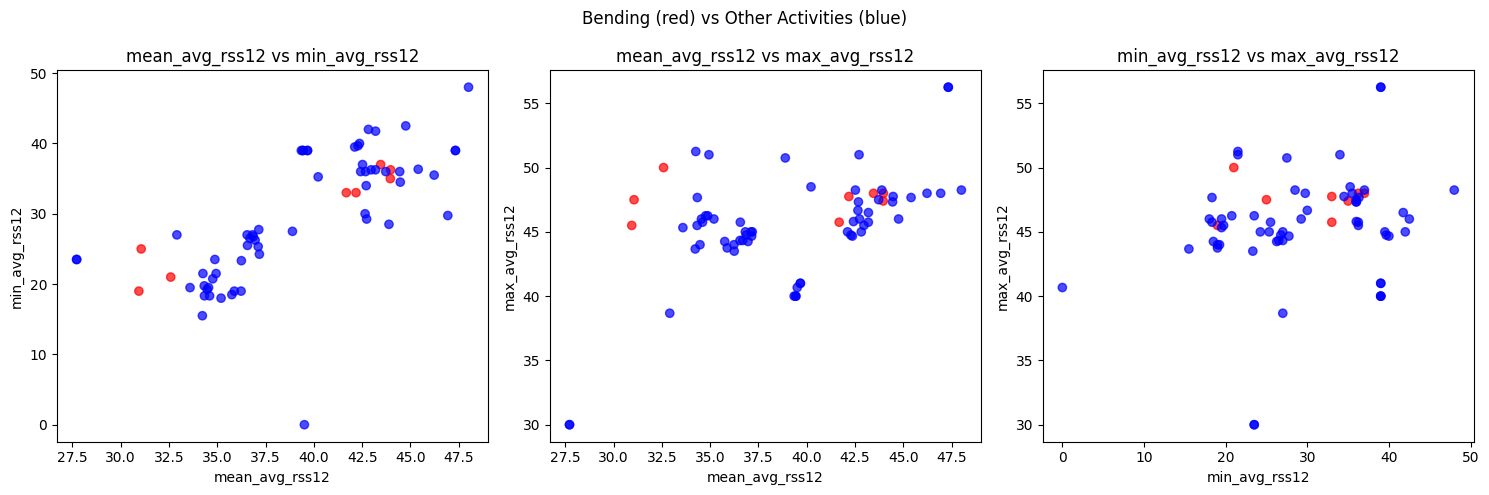

In [11]:
import matplotlib.pyplot as plt

selected_features = ['mean_avg_rss12', 'min_avg_rss12', 'max_avg_rss12']  # example choice

colors = train_df['is_bending'].map({True: 'red', False: 'blue'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    (selected_features[0], selected_features[1]),
    (selected_features[0], selected_features[2]),
    (selected_features[1], selected_features[2]),
]

for ax, (fx, fy) in zip(axes, pairs):
    ax.scatter(train_df[fx], train_df[fy], c=colors, alpha=0.7)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}')

plt.suptitle('Bending (red) vs Other Activities (blue)')
plt.tight_layout()
plt.show()

Question4

In [12]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

out_dir = '/content/drive/MyDrive/USC_Summer26/EE559/HW5_outputs'
os.makedirs(out_dir, exist_ok=True)

assert 'train_files' in dir() and 'load_instance' in dir(), 'Run your HW4 cells first!'

Generalized feature extraction

In [13]:
def extract_features_l(df, l=1):
    feats = {}
    for col in df.columns:
        segments = np.array_split(df[col].dropna().values, l)
        for k, seg in enumerate(segments, start=1):
            s = pd.Series(seg)
            suffix = f'{col}_{k}' if l > 1 else col
            feats[f'min_{suffix}']    = s.min()
            feats[f'max_{suffix}']    = s.max()
            feats[f'mean_{suffix}']   = s.mean()
            feats[f'median_{suffix}'] = s.median()
            feats[f'std_{suffix}']    = s.std()
            feats[f'q1_{suffix}']     = s.quantile(0.25)
            feats[f'q3_{suffix}']     = s.quantile(0.75)
    return feats

def build_dataset_l(file_list, l=1):
    rows = []
    for path, label in file_list:
        feats = extract_features_l(load_instance(path), l=l)
        feats['label'] = label
        rows.append(feats)
    return pd.DataFrame(rows)

def get_Xy(df, binary=True):
    feature_cols = [c for c in df.columns if c not in ('label', 'is_bending')]
    X = df[feature_cols].values
    if binary:
        y = df['label'].isin(['bending1', 'bending2']).astype(int).values
    else:
        y = df['label'].values
    return X, y, feature_cols

def get_tables(l):
    tr_path = os.path.join(out_dir, f'train_l{l}.csv')
    te_path = os.path.join(out_dir, f'test_l{l}.csv')
    if os.path.exists(tr_path) and os.path.exists(te_path):
        return pd.read_csv(tr_path), pd.read_csv(te_path)
    tr = build_dataset_l(train_files, l)
    te = build_dataset_l(test_files, l)
    tr.to_csv(tr_path, index=False); te.to_csv(te_path, index=False)
    return tr, te

4(a)i

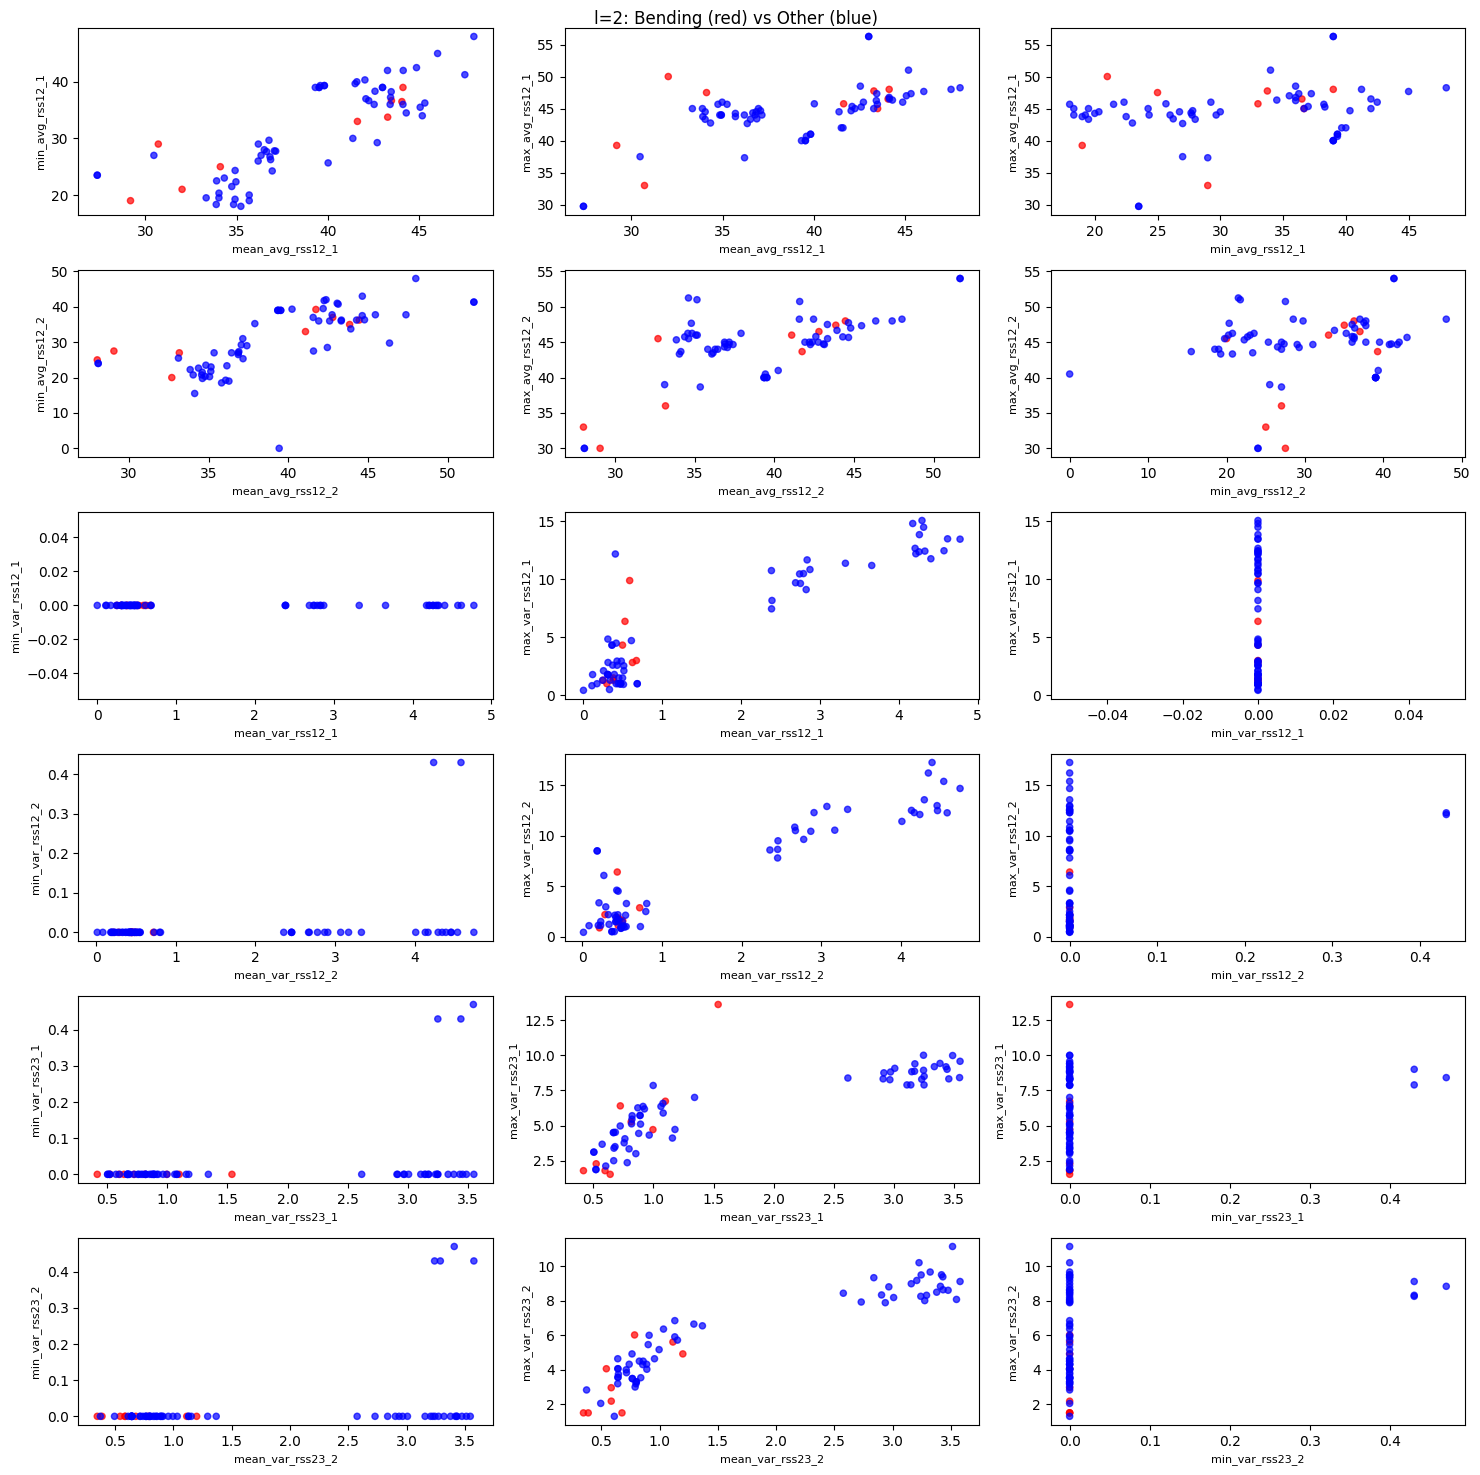

In [14]:
train_l2, _ = get_tables(2)
train_l2['is_bending'] = train_l2['label'].isin(['bending1', 'bending2'])
colors = train_l2['is_bending'].map({True: 'red', False: 'blue'})

series_136 = ['avg_rss12', 'var_rss12', 'var_rss23']
sel = ['mean', 'min', 'max']

fig, axes = plt.subplots(len(series_136)*2, 3, figsize=(15, 5*len(series_136)*2//2))
r = 0
for ts in series_136:
    for half in (1, 2):
        names = [f'{f}_{ts}_{half}' for f in sel]
        pairs = [(names[0], names[1]), (names[0], names[2]), (names[1], names[2])]
        for c, (fx, fy) in enumerate(pairs):
            ax = axes[r, c]
            ax.scatter(train_l2[fx], train_l2[fy], c=colors, alpha=0.7, s=20)
            ax.set_xlabel(fx, fontsize=8); ax.set_ylabel(fy, fontsize=8)
        r += 1
plt.suptitle('l=2: Bending (red) vs Other (blue)')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, '4ai_scatter_l2.png'), dpi=150)
plt.show()

Discussion:
\
The half-series feature clouds look essentially the same as the full-series ones from 3(c)v
\
The series are roughly stationary within an instance, so splitting does not create considerably different separability; it just doubles the number of correlated features.

Data Cleaning

In [15]:
tr, _ = get_tables(1)
X, y, feat_names = get_Xy(tr)
nan_cols = np.array(feat_names)[np.isnan(X).any(axis=0)]
print('NaN count:', np.isnan(X).sum())
print('Columns with NaN:', nan_cols)
print('Rows with NaN:', tr.loc[np.isnan(X).any(axis=1), 'label'].tolist())

NaN count: 0
Columns with NaN: []
Rows with NaN: []


In [16]:
for path, label in train_files + test_files:
    if label == 'bending2':
        df = load_instance(path)
        if len(df) == 0 or df.isna().all().all():
            print('BAD FILE:', path)
            with open(path) as f:
                lines = [l for l in f if not l.startswith('#')]
            print(repr(lines[0]))

BAD FILE: /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/bending2/dataset4.csv
'0 32.50 0.50 0.00 0.00 19.00 1.00 \n'


In [17]:
def load_instance(filepath):
    try:
        df = pd.read_csv(filepath, comment='#', header=None,
                          names=['time','avg_rss12','var_rss12','avg_rss13',
                                 'var_rss13','avg_rss23','var_rss23'])
    except pd.errors.ParserError:
        with open(filepath) as f:
            raw_lines = f.readlines()
        cleaned = [l.rstrip('\n').rstrip(',') + '\n'
                   for l in raw_lines if not l.startswith('#')]
        from io import StringIO
        df = pd.read_csv(StringIO(''.join(cleaned)), header=None,
                          names=['time','avg_rss12','var_rss12','avg_rss13',
                                 'var_rss13','avg_rss23','var_rss23'])

    df = df.drop(columns='time')
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all')
    if len(df) < 10:
        df = pd.read_csv(filepath, comment='#', header=None, sep=r'[,\s]+',
                          engine='python',
                          names=['time','avg_rss12','var_rss12','avg_rss13',
                                 'var_rss13','avg_rss23','var_rss23'])
        df = df.drop(columns='time').apply(pd.to_numeric, errors='coerce')
        df = df.dropna(how='all')

    return df

In [18]:
import glob
for f in glob.glob(os.path.join(out_dir, 'train_l*.csv')) + \
         glob.glob(os.path.join(out_dir, 'test_l*.csv')) + \
         [os.path.join(out_dir, '4aii_cv_results.csv')]:
    if os.path.exists(f): os.remove(f)
tr, _ = get_tables(1)
X, y, _ = get_Xy(tr)
print('NaN count:', np.isnan(X).sum())

NaN count: 0


4(a)ii_LR

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ckpt = os.path.join(out_dir, '4aii_cv_results.csv')
cv_results = pd.read_csv(ckpt).to_dict('records') if os.path.exists(ckpt) else []
done_l = {r['l'] for r in cv_results}

for l in range(1, 21):
    if l in done_l: continue
    tr, _ = get_tables(l)
    X, y, _ = get_Xy(tr)
    p_grid = sorted(set(np.linspace(1, X.shape[1], num=10, dtype=int)))
    for p in p_grid:
        pipe = Pipeline([
            ('sc', StandardScaler()),
            ('rfe', RFE(LogisticRegression(C=1e6, max_iter=300),
                        n_features_to_select=int(p))),
            ('clf', LogisticRegression(C=1e6, max_iter=300)),
        ])
        acc = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy').mean()
        cv_results.append(dict(l=l, p=int(p), cv_acc=acc))
    pd.DataFrame(cv_results).to_csv(ckpt, index=False)
    print(f'l={l:2d} done')

cv_df = pd.DataFrame(cv_results)
best = cv_df.loc[cv_df.cv_acc.idxmax()]
BEST_L, BEST_P = int(best.l), int(best.p)
print(f'Best (l, p) = ({BEST_L}, {BEST_P}), CV accuracy = {best.cv_acc:.4f}')

l= 1 done
l= 2 done
l= 3 done
l= 4 done
l= 5 done
l= 6 done
l= 7 done
l= 8 done
l= 9 done
l=10 done
l=11 done
l=12 done
l=13 done
l=14 done
l=15 done
l=16 done
l=17 done
l=18 done
l=19 done
l=20 done
Best (l, p) = (1, 23), CV accuracy = 0.9857


4(a)iii

Perfect separation → p-values unreliable
         feature       beta  p_value
       intercept -10.440070      NaN
   min_avg_rss12  -1.806370      NaN
   max_avg_rss12   1.248179      NaN
  mean_avg_rss12  -1.142893      NaN
median_avg_rss12  -0.541275      NaN
    q3_avg_rss12  -2.377093      NaN
   max_var_rss12  -1.225083      NaN
   max_avg_rss13   1.509198      NaN
median_avg_rss13  -0.730249      NaN
   std_avg_rss13  -1.333024      NaN
    q3_avg_rss13  -1.321268      NaN
   max_var_rss13   1.816028      NaN
median_var_rss13  -0.789391      NaN
    q1_var_rss13  -0.879165      NaN
   min_avg_rss23   3.927118      NaN
   max_avg_rss23   4.395893      NaN
  mean_avg_rss23   1.792229      NaN
    q1_avg_rss23   1.344657      NaN
    q3_avg_rss23   0.954264      NaN
  mean_var_rss23  -0.688607      NaN
median_var_rss23  -0.720464      NaN
   std_var_rss23  -1.176649      NaN
    q1_var_rss23  -1.458426      NaN
    q3_var_rss23  -0.678321      NaN
Train confusion matrix:
 [[60  0]


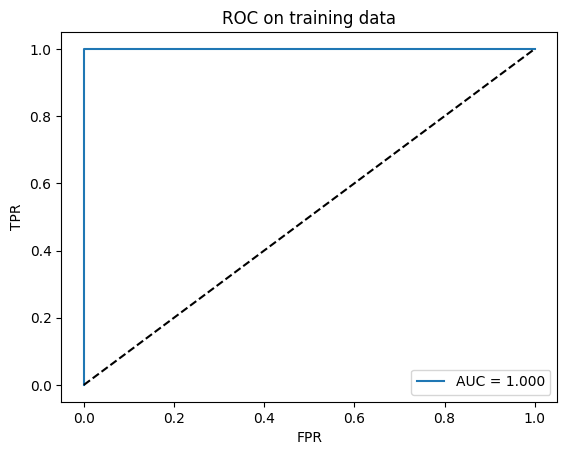

In [29]:
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

tr, te = get_tables(BEST_L)
Xtr, ytr, feat_names = get_Xy(tr)
Xte, yte, _ = get_Xy(te)

scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

rfe = RFE(LogisticRegression(C=1e6, max_iter=500),
          n_features_to_select=BEST_P).fit(Xtr_s, ytr)
sel_mask = rfe.support_
sel_names = np.array(feat_names)[sel_mask]

clf = LogisticRegression(C=1e6, max_iter=500).fit(Xtr_s[:, sel_mask], ytr)

try:
    sm_fit = sm.Logit(ytr, sm.add_constant(Xtr_s[:, sel_mask])).fit(disp=0, maxiter=200)
    pvals = sm_fit.pvalues
except Exception:
    pvals = np.full(BEST_P + 1, np.nan)
    print('Perfect separation → p-values unreliable')

coef_table = pd.DataFrame({'feature': ['intercept'] + list(sel_names),
                           'beta': np.r_[clf.intercept_, clf.coef_.ravel()],
                           'p_value': pvals})
print(coef_table.to_string(index=False))

print('Train confusion matrix:\n', confusion_matrix(ytr, clf.predict(Xtr_s[:, sel_mask])))
fpr, tpr, _ = roc_curve(ytr, clf.predict_proba(Xtr_s[:, sel_mask])[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr,tpr):.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC on training data'); plt.legend(); plt.show()

4(a)iv

In [21]:
yte_hat = clf.predict(Xte_s[:, sel_mask])
print(f'Test accuracy = {(yte_hat == yte).mean():.4f}  vs  CV accuracy = {best.cv_acc:.4f}')
print('Test confusion matrix:\n', confusion_matrix(yte, yte_hat))

Test accuracy = 1.0000  vs  CV accuracy = 0.9857
Test confusion matrix:
 [[15  0]
 [ 0  4]]


4(a)v

In [22]:
print('Max |beta| =', np.abs(clf.coef_).max())
print('n_iter =', clf.n_iter_)

Max |beta| = 4.395893109844594
n_iter = [13]


4(a)vi

Case-control test confusion matrix:
 [[14  1]
 [ 0  4]]


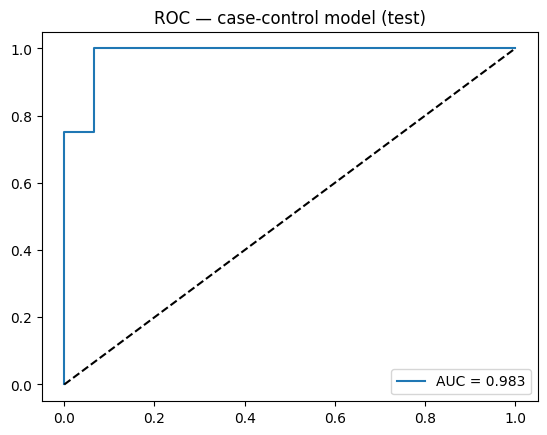

In [23]:
from sklearn.utils import resample

tr_bend  = tr[tr['label'].isin(['bending1','bending2'])]
tr_other = tr[~tr['label'].isin(['bending1','bending2'])]
tr_cc = pd.concat([tr_bend,
                   resample(tr_other, n_samples=len(tr_bend),
                            replace=False, random_state=42)])
Xcc, ycc, _ = get_Xy(tr_cc)
clf_cc = LogisticRegression(C=1e6, max_iter=500).fit(
    scaler.transform(Xcc)[:, sel_mask], ycc)

pi1 = ytr.mean(); pi0 = 1 - pi1
clf_cc.intercept_ += np.log(pi1/pi0)

print('Case-control test confusion matrix:\n',
      confusion_matrix(yte, clf_cc.predict(Xte_s[:, sel_mask])))
fpr, tpr, _ = roc_curve(yte, clf_cc.predict_proba(Xte_s[:, sel_mask])[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr,tpr):.3f}')
plt.plot([0,1],[0,1],'k--'); plt.title('ROC — case-control model (test)')
plt.legend(); plt.show()

4(b)i_L1_logistic regression

In [24]:
from sklearn.linear_model import LogisticRegressionCV

ckpt_b = os.path.join(out_dir, '4b_l1_results.csv')
l1_results = pd.read_csv(ckpt_b).to_dict('records') if os.path.exists(ckpt_b) else []
done_l = {r['l'] for r in l1_results}

for l in range(1, 21):
    if l in done_l: continue
    tr_l, _ = get_tables(l)
    X, y, _ = get_Xy(tr_l)
    Xs = StandardScaler().fit_transform(X)
    lcv = LogisticRegressionCV(Cs=20, cv=skf, penalty='l1', solver='liblinear',
                               scoring='accuracy', max_iter=500).fit(Xs, y)
    acc = lcv.scores_[1].mean(axis=0).max()
    l1_results.append(dict(l=l, best_C=float(lcv.C_[0]), cv_acc=acc))
    pd.DataFrame(l1_results).to_csv(ckpt_b, index=False)
    print(f'l={l:2d}  best C={lcv.C_[0]:.3g}  cv_acc={acc:.4f}')

l1_df = pd.DataFrame(l1_results)
best_l1 = l1_df.loc[l1_df.cv_acc.idxmax()]
BEST_L_L1 = int(best_l1.l)
print('Best:', dict(best_l1))

tr_l, te_l = get_tables(BEST_L_L1)
X, y, _ = get_Xy(tr_l); Xt, yt, _ = get_Xy(te_l)
sc_b = StandardScaler().fit(X)
final_l1 = LogisticRegressionCV(Cs=20, cv=skf, penalty='l1', solver='liblinear',
                                max_iter=500).fit(sc_b.transform(X), y)
print(f'L1 test accuracy = {(final_l1.predict(sc_b.transform(Xt)) == yt).mean():.4f}')
print(f'Nonzero coefficients: {(final_l1.coef_ != 0).sum()} / {final_l1.coef_.size}')

Best: {'l': np.float64(1.0), 'best_C': np.float64(3792.690190732246), 'cv_acc': np.float64(0.9857142857142858)}
L1 test accuracy = 1.0000
Nonzero coefficients: 9 / 42


4(b)ii

L1 gets everything done in one step and is stable in all cases,meanwhile the p-value method involves more steps, and its theoretical assumptions are violated by this dataset.



4(c)i

Multinomial L1 test error = 0.1579


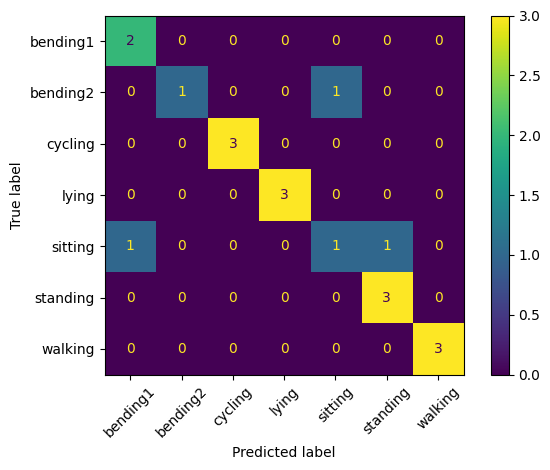

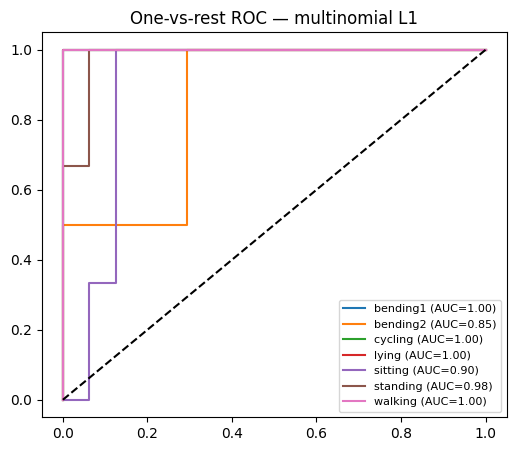

In [25]:
ckpt_c = os.path.join(out_dir, '4ci_multinomial.csv')
mc_results = pd.read_csv(ckpt_c).to_dict('records') if os.path.exists(ckpt_c) else []
done_l = {r['l'] for r in mc_results}

for l in range(1, 21):
    if l in done_l: continue
    tr_l, _ = get_tables(l)
    X, y, _ = get_Xy(tr_l, binary=False)
    Xs = StandardScaler().fit_transform(X)
    lcv = LogisticRegressionCV(Cs=10, cv=skf, penalty='l1', solver='saga',
                               multi_class='multinomial', max_iter=2000,
                               scoring='accuracy').fit(Xs, y)
    acc = np.mean([s.mean(axis=0).max() for s in lcv.scores_.values()])
    mc_results.append(dict(l=l, cv_acc=acc))
    pd.DataFrame(mc_results).to_csv(ckpt_c, index=False)
    print(f'l={l:2d}  cv_acc={acc:.4f}')

mc_df = pd.DataFrame(mc_results)
BEST_L_MC = int(mc_df.loc[mc_df.cv_acc.idxmax(), 'l'])

tr_l, te_l = get_tables(BEST_L_MC)
Xtr, ytr7, _ = get_Xy(tr_l, binary=False); Xte, yte7, _ = get_Xy(te_l, binary=False)
sc_c = StandardScaler().fit(Xtr)
final_mc = LogisticRegressionCV(Cs=10, cv=skf, penalty='l1', solver='saga',
                                multi_class='multinomial', max_iter=3000
                                ).fit(sc_c.transform(Xtr), ytr7)
yh = final_mc.predict(sc_c.transform(Xte))
err_mc = (yh != yte7).mean()
print(f'Multinomial L1 test error = {err_mc:.4f}')
ConfusionMatrixDisplay.from_predictions(yte7, yh, xticks_rotation=45)
plt.tight_layout(); plt.show()

from sklearn.preprocessing import label_binarize
classes = final_mc.classes_
Yb = label_binarize(yte7, classes=classes)
proba = final_mc.predict_proba(sc_c.transform(Xte))
plt.figure(figsize=(6,5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Yb[:, i], proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr,tpr):.2f})')
plt.plot([0,1],[0,1],'k--'); plt.legend(fontsize=8)
plt.title('One-vs-rest ROC — multinomial L1'); plt.show()

4(c)ii_Naive Bayes

In [26]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler

ckpt_nb = os.path.join(out_dir, '4cii_nb.csv')
nb_results = pd.read_csv(ckpt_nb).to_dict('records') if os.path.exists(ckpt_nb) else []
done_l = {r['l'] for r in nb_results}

for l in range(1, 21):
    if l in done_l: continue
    tr_l, _ = get_tables(l)
    X, y, _ = get_Xy(tr_l, binary=False)
    acc_g = cross_val_score(GaussianNB(), X, y, cv=skf).mean()
    pipe_m = Pipeline([('mm', MinMaxScaler()), ('nb', MultinomialNB())])  # 需非负特征
    acc_m = cross_val_score(pipe_m, X, y, cv=skf).mean()
    nb_results.append(dict(l=l, gaussian=acc_g, multinomial=acc_m))
    pd.DataFrame(nb_results).to_csv(ckpt_nb, index=False)

nb_df = pd.DataFrame(nb_results)
print(nb_df.to_string(index=False))

nb_test_err = {}
for kind, col in [('GaussianNB','gaussian'), ('MultinomialNB','multinomial')]:
    lb = int(nb_df.loc[nb_df[col].idxmax(), 'l'])
    tr_l, te_l = get_tables(lb)
    Xtr, ytr7, _ = get_Xy(tr_l, binary=False); Xte, yte7, _ = get_Xy(te_l, binary=False)
    model = (GaussianNB().fit(Xtr, ytr7) if col == 'gaussian'
             else Pipeline([('mm', MinMaxScaler()), ('nb', MultinomialNB())]).fit(Xtr, ytr7))
    nb_test_err[kind] = (model.predict(Xte) != yte7).mean()
    print(f'{kind}: best l={lb}, test error={nb_test_err[kind]:.4f}')

 l  gaussian  multinomial
 1  0.857143     0.723077
 2  0.827473     0.751648
 3  0.681319     0.723077
 4  0.725275     0.723077
 5  0.652747     0.723077
 6  0.652747     0.694505
 7  0.695604     0.694505
 8  0.667033     0.723077
 9  0.638462     0.694505
10  0.681319     0.680220
11  0.682418     0.665934
12  0.594505     0.665934
13  0.610989     0.680220
14  0.553846     0.680220
15  0.565934     0.665934
16  0.553846     0.665934
17  0.567033     0.651648
18  0.480220     0.680220
19  0.538462     0.680220
20  0.537363     0.651648
GaussianNB: best l=1, test error=0.1053
MultinomialNB: best l=2, test error=0.2105


4(c)iii_PCA+Gaussian NB

Best (l, p) = (1, 10), CV acc = 0.9143
PCA+GaussianNB test error = 0.1579


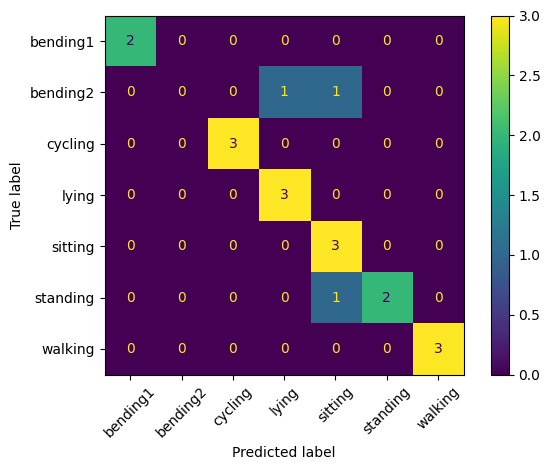

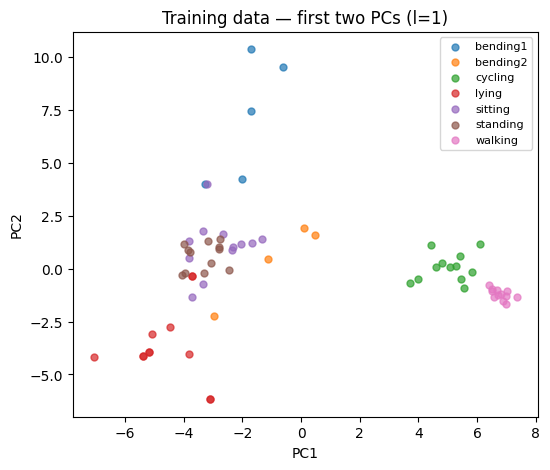

In [27]:
from sklearn.decomposition import PCA

ckpt_p = os.path.join(out_dir, '4ciii_pca_nb.csv')
pca_results = pd.read_csv(ckpt_p).to_dict('records') if os.path.exists(ckpt_p) else []
done_l = {r['l'] for r in pca_results}

for l in range(1, 21):
    if l in done_l: continue
    tr_l, _ = get_tables(l)
    X, y, _ = get_Xy(tr_l, binary=False)
    n_max = min(int(X.shape[0]*0.8) - 1, X.shape[1], 20)
    for p in range(1, n_max + 1):
        pipe = Pipeline([('sc', StandardScaler()),
                         ('pca', PCA(n_components=p)),
                         ('nb', GaussianNB())])
        acc = cross_val_score(pipe, X, y, cv=skf).mean()
        pca_results.append(dict(l=l, p=p, cv_acc=acc))
    pd.DataFrame(pca_results).to_csv(ckpt_p, index=False)
    print(f'l={l:2d} done')

pca_df = pd.DataFrame(pca_results)
bp = pca_df.loc[pca_df.cv_acc.idxmax()]
L_PCA, P_PCA = int(bp.l), int(bp.p)
print(f'Best (l, p) = ({L_PCA}, {P_PCA}), CV acc = {bp.cv_acc:.4f}')

tr_l, te_l = get_tables(L_PCA)
Xtr, ytr7, _ = get_Xy(tr_l, binary=False); Xte, yte7, _ = get_Xy(te_l, binary=False)
pipe = Pipeline([('sc', StandardScaler()),
                 ('pca', PCA(n_components=P_PCA)),
                 ('nb', GaussianNB())]).fit(Xtr, ytr7)
yh = pipe.predict(Xte)
err_pca = (yh != yte7).mean()
print(f'PCA+GaussianNB test error = {err_pca:.4f}')
ConfusionMatrixDisplay.from_predictions(yte7, yh, xticks_rotation=45)
plt.tight_layout(); plt.show()

Z = pipe.named_steps['pca'].transform(pipe.named_steps['sc'].transform(Xtr))[:, :2]
plt.figure(figsize=(6,5))
for cls in np.unique(ytr7):
    m = ytr7 == cls
    plt.scatter(Z[m,0], Z[m,1], s=25, alpha=0.7, label=cls)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(fontsize=8)
plt.title(f'Training data — first two PCs (l={L_PCA})'); plt.show()

4(c)iv_comparison

In [28]:
summary = pd.DataFrame({
    'method': ['Multinomial L1 logistic', 'GaussianNB', 'MultinomialNB', 'PCA + GaussianNB'],
    'test_error': [err_mc, nb_test_err['GaussianNB'],
                   nb_test_err['MultinomialNB'], err_pca]})
print(summary.to_string(index=False))

                 method  test_error
Multinomial L1 logistic    0.157895
             GaussianNB    0.105263
          MultinomialNB    0.210526
       PCA + GaussianNB    0.157895
